# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  0%|          | 32.8k/9.91M [00:00<00:32, 303kB/s]

  1%|          | 65.5k/9.91M [00:00<00:33, 295kB/s]

  1%|          | 98.3k/9.91M [00:00<00:32, 299kB/s]

  1%|▏         | 131k/9.91M [00:00<00:33, 295kB/s] 

...

 81%|████████▏ | 1.34M/1.65M [00:01<00:00, 1.42MB/s]

100%|██████████| 1.65M/1.65M [00:01<00:00, 968kB/s] 

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 2.97MB/s]

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[ 0.2517,  0.0365, -0.5494,  0.2796,  0.2277, -0.1590,  0.3219, -0.4579,
         -0.2006,  0.4491]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [7]:
n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [8]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Epoch [1/5], Train Loss: 0.4102, Train Acc: 0.8835, Val Loss: 0.3445, Val Acc: 0.8998


Epoch [2/5], Train Loss: 0.3110, Train Acc: 0.9123, Val Loss: 0.3081, Val Acc: 0.9136


Epoch [3/5], Train Loss: 0.2949, Train Acc: 0.9171, Val Loss: 0.3032, Val Acc: 0.9156


Epoch [4/5], Train Loss: 0.2869, Train Acc: 0.9186, Val Loss: 0.2956, Val Acc: 0.9173


Epoch [5/5], Train Loss: 0.2807, Train Acc: 0.9205, Val Loss: 0.2936, Val Acc: 0.9197


In [9]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2807
Última acurácia de treinamento: 0.9205
Última perda de validação: 0.2936
Última acurácia de validação: 0.9197


### Visualizando a evolução da perda e acurácia

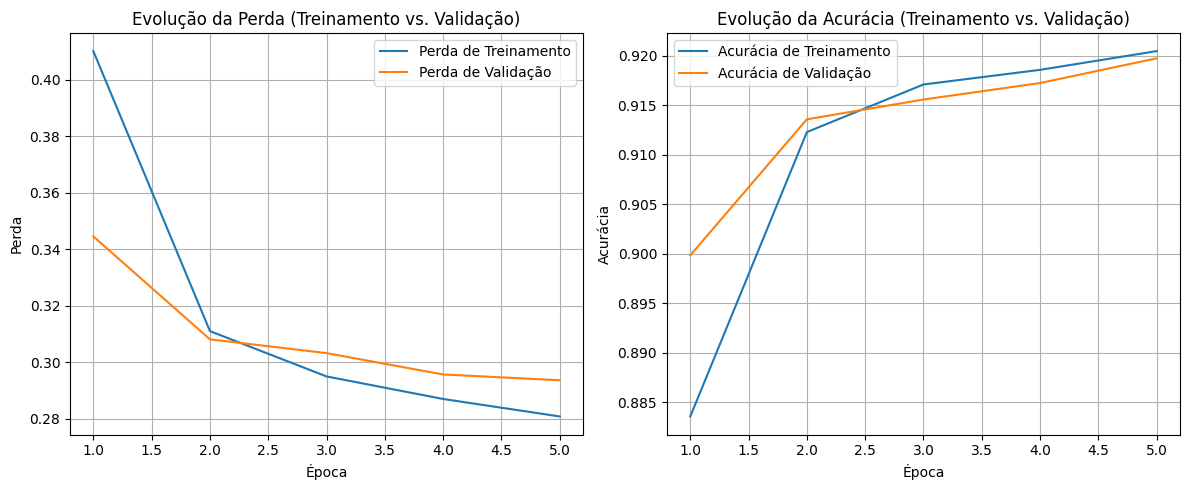

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?
2. Em uma época, quantos mini-batches existem?
3. Qual é a definição de época?

## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

## Conclusões sobre os experimentos deste notebook


---
## Exercícios — Soluções

**Nome:** Thiago Pereira Magalhães | **Email:** tpm3@cesar.school


### Exercício 1 — Re-treinamento com Print por Mini-batch


In [11]:
# Exercício 1: Loop com print por mini-batch e comparação de batch_size
import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
import torchvision
import matplotlib.pyplot as plt

dataset_dir_34 = 'MNIST/'
train_ds_34 = MNIST(dataset_dir_34, train=True, download=True,
                    transform=torchvision.transforms.ToTensor())

results = {}  # armazenar losses por batch_size

for batch_sz in [32, 100, 500]:
    loader_34 = DataLoader(train_ds_34, batch_size=batch_sz, shuffle=True)
    torch.manual_seed(42)
    model_34 = torch.nn.Linear(28*28, 10)
    crit_34 = torch.nn.CrossEntropyLoss()
    opt_34 = torch.optim.SGD(model_34.parameters(), lr=0.5)
    n_epochs_34 = 3
    all_losses = []

    for epoch in range(n_epochs_34):
        for batch_i, (xb, yb) in enumerate(loader_34):
            inp = Variable(xb.view(-1, 28*28))
            out = model_34(inp)
            loss = crit_34(out, Variable(yb))
            opt_34.zero_grad()
            loss.backward()
            opt_34.step()
            all_losses.append(loss.item())

            # Print por mini-batch estilo solicitado
            n_batches = len(loader_34)
            if batch_i % 100 == 0 and batch_sz == 100:  # print apenas para batch_size=100
                print(f'  Época: {epoch+1}/{n_epochs_34}, batch: {batch_i+1}/{n_batches}')

    results[batch_sz] = all_losses
    print(f'batch_size={batch_sz} | Loss final: {all_losses[-1]:.4f}')

print('\nTreinamento concluído!')


batch_size=32 | Loss final: 0.4897
  Época: 1/3, batch: 1/600


  Época: 1/3, batch: 101/600


  Época: 1/3, batch: 201/600


  Época: 1/3, batch: 301/600


  Época: 1/3, batch: 401/600


...

  Época: 3/3, batch: 301/600


  Época: 3/3, batch: 401/600


  Época: 3/3, batch: 501/600


batch_size=100 | Loss final: 0.3139


batch_size=500 | Loss final: 0.2714

Treinamento concluído!


### Exercício 2 — Comparação de Loss por Tamanho de Mini-batch


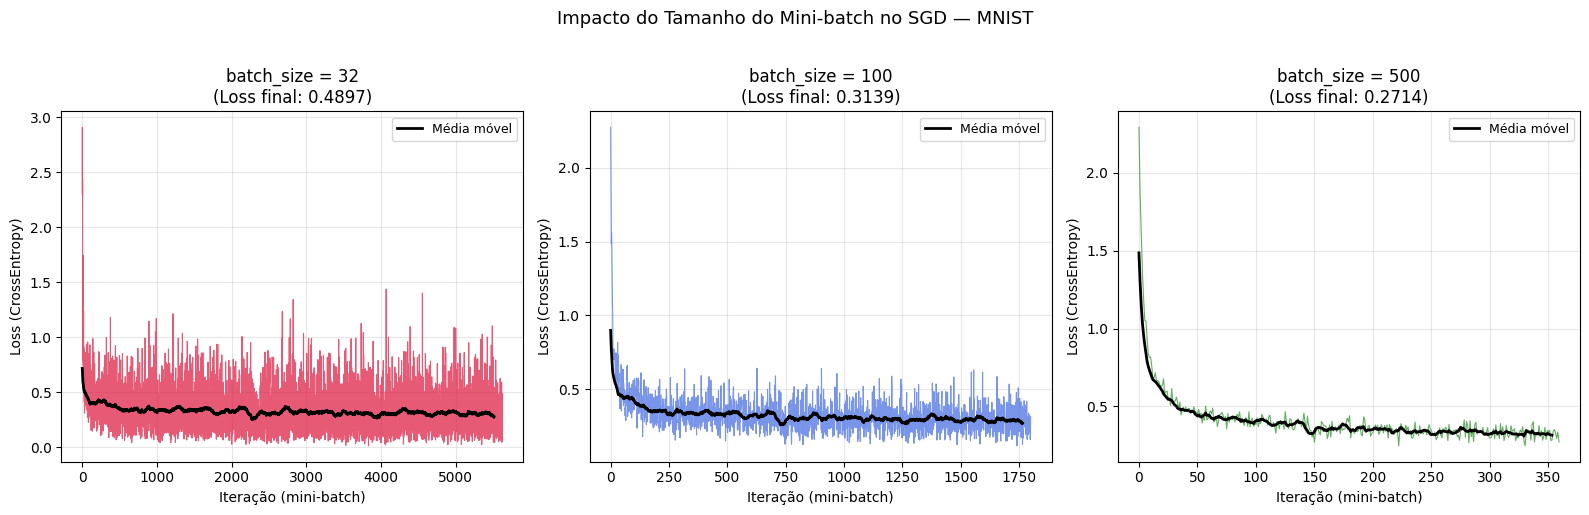

In [12]:
# Plot comparativo dos losses por batch_size
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_bs = {'32': 'crimson', '100': 'royalblue', '500': 'forestgreen'}

for ax, (bs, losses_bs) in zip(axes, results.items()):
    ax.plot(losses_bs, alpha=0.7, linewidth=0.8, color=colors_bs[str(bs)])
    ax.set_title(f'batch_size = {bs}\n(Loss final: {losses_bs[-1]:.4f})')
    ax.set_xlabel('Iteração (mini-batch)')
    ax.set_ylabel('Loss (CrossEntropy)')
    ax.grid(True, alpha=0.3)
    # Linha de tendência (média móvel)
    import numpy as np
    window = max(1, len(losses_bs) // 50)
    smooth = np.convolve(losses_bs, np.ones(window)/window, mode='valid')
    ax.plot(smooth, color='black', linewidth=2, label='Média móvel')
    ax.legend(fontsize=9)

plt.suptitle('Impacto do Tamanho do Mini-batch no SGD — MNIST', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Análise — Por que o Loss do SGD oscila?

**Nome:** Thiago Pereira Magalhães | **Email:** tpm3@cesar.school

### Oscilações (Ruídos) no Loss do SGD por Mini-batch

O **Gradiente Descendente Estocástico (SGD) por mini-batch** estima o gradiente verdadeiro (Full Batch) usando apenas uma fração dos dados em cada passo. Isso introduz **variância na estimativa do gradiente**:

$$\nabla J_{mini} \approx \nabla J_{full} + \epsilon$$

onde $\epsilon$ é um ruído estatístico que depende do tamanho do batch.

**Comparação por tamanho de batch:**

| batch_size | Variância do Gradiente | Oscilação na Loss | Velocidade/Época |
|---|---|---|---|
| 32 | Alta | Muito ruidosa | Mais rápida |
| 100 | Moderada | Moderada | Moderada |
| 500+ | Baixa | Suave | Mais lenta |
| Full Batch | Zero | Monotônica | Muito lenta |

### Por que oscilações podem ser benéficas?
O ruído do SGD mini-batch age como um **regularizador implícito** — permite escapar de mínimos locais rasos e encontrar mínimos mais generalizáveis. Batches menores tendem a encontrar **flat minima** (mínimos amplos), que geralmente generalizam melhor.

### Definições
- **Mini-batch:** subconjunto de amostras usado para calcular o gradiente em um passo.
- **Época:** uma passagem completa por **todos** os dados de treinamento. Com batch_size=100 e 60.000 amostras → 600 mini-batches por época.


## 📚 Perguntas — Respostas

1. **Tamanho do mini-batch:** 100 amostras (definido em `batch_size`).
2. **Quantos mini-batches por época:** com 60.000 amostras de treino e batch_size=100 → **600 mini-batches**.
3. **Definição de época:** uma época é completada quando o modelo processou **todas as amostras** do dataset de treinamento exatamente uma vez. É a unidade de medida de progresso do treinamento.

## 📚 Principais Aprendizados

O treinamento com mini-batches via DataLoader é o padrão na prática de Deep Learning por três razões:
1. **Memória:** grandes datasets não cabem na RAM/GPU — mini-batches resolvem isso.
2. **Velocidade:** mini-batches permitem atualizações mais frequentes que Full Batch.
3. **Generalização:** o ruído estatístico do SGD melhora a capacidade de generalização.
